# **xAI**

The following notebook contains the explainabilty of advanced classificaton models

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd

from collections import defaultdict

# **Data Preparation**

In [2]:
df = pd.read_csv('../dataset/cmi_internet_cleaned.csv')
X = df.drop(columns="sii").values

## 1. EBM

EBM code can be found at the end of gbm.ipynb since its explanation is part of the model's nature

## 2. XGBoost

In [3]:
import numpy as np
import pandas as pd
from collections import Counter
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler                
from imblearn.over_sampling import ADASYN                         
from imblearn.under_sampling import EditedNearestNeighbours        
from imblearn.pipeline import Pipeline as ImbPipeline              

# =========================================================================
# 1. ACCORPAMENTO CLINICO E PREPARAZIONE DATI (3 Classi allineate a zero)
# =========================================================================
print("=== STEP 1: CLASS AGGREGATION & ALIGNMENT ===")

y_clean_3classes = df['sii'].replace({3: 2})

if y_clean_3classes.min() == 1:
    y_clean_3classes = y_clean_3classes - 1

print("Nuova distribuzione delle 3 macro-classi (0, 1, 2):")
print(Counter(y_clean_3classes))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean_3classes, test_size=0.3, random_state=42, stratify=y_clean_3classes
)

# =========================================================================
# 2. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefisso 'xgb__')
# =========================================================================
param_dist_hybrid_xgb = {
    # Parametri di ADASYN ed ENN
    'adasyn__n_neighbors': [3, 5, 7],
    'enn__n_neighbors': [3, 5, 7],
    'enn__kind_sel': ['all', 'mode'],
    
    # Parametri di XGBoost
    'xgb__n_estimators': [50, 100, 200, 300],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__max_depth': [3, 4, 5, 7, 9], 
    'xgb__min_child_weight': [1, 3, 5, 7],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0],
    'xgb__gamma': [0, 0.1, 0.2, 0.5, 1.0, 5.0],
    'xgb__reg_alpha': [0, 0.1, 1.0],   
    'xgb__reg_lambda': [1.0, 5.0, 10.0] 
}

# =========================================================================
# 3. COSTRUZIONE DELLA PIPELINE IBRIDA PROTETTA (Con Scaler)
# =========================================================================
adasyn_sampler = ADASYN(random_state=42)
enn_sampler = EditedNearestNeighbours(sampling_strategy='all')

xgb_base = XGBClassifier(
    objective='multi:softprob', 
    eval_metric='mlogloss',
    n_jobs=-1, 
    random_state=42
)

# L'ordine è tassativo: prima scali, poi bilanci, infine passi a XGBoost
pipeline_xgb_hybrid = ImbPipeline([
    ('scaler', StandardScaler()), # Fase 1: Standardizzazione per lo spazio dei K-NN
    ('adasyn', adasyn_sampler),   # Fase 2: Oversampling adattivo sui dati scalati
    ('enn', enn_sampler),         # Fase 3: Pulizia chirurgica delle sovrapposizioni
    ('xgb', xgb_base)             # Fase 4: Classificazione tramite Gradient Boosting
])

# =========================================================================
# 4. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("\n=== STEP 2: HYPERPARAMETER TUNING (ADASYN + ENN + XGBOOST) ===")

random_search_hybrid_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb_hybrid,
    param_distributions=param_dist_hybrid_xgb,
    n_iter=30,                     
    cv=5,                          
    scoring='balanced_accuracy',   
    n_jobs=1,                      
    random_state=42,
    verbose=1
)

random_search_hybrid_xgb.fit(X_train, y_train)
best_pipeline_xgb = random_search_hybrid_xgb.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_hybrid_xgb.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_hybrid_xgb.best_score_:.4f}\n")

=== STEP 1: CLASS AGGREGATION & ALIGNMENT ===
Nuova distribuzione delle 3 macro-classi (0, 1, 2):
Counter({0: 5476, 1: 1444, 2: 919})

=== STEP 2: HYPERPARAMETER TUNING (ADASYN + ENN + XGBOOST) ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'xgb__subsample': 0.6, 'xgb__reg_lambda': 5.0, 'xgb__reg_alpha': 1.0, 'xgb__n_estimators': 100, 'xgb__min_child_weight': 7, 'xgb__max_depth': 9, 'xgb__learning_rate': 0.1, 'xgb__gamma': 0, 'xgb__colsample_bytree': 1.0, 'enn__n_neighbors': 5, 'enn__kind_sel': 'mode', 'adasyn__n_neighbors': 3}
Best Balanced Accuracy Score (CV): 0.4921



### SHAP

In [4]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# 1. Inizializza l'esploratore SHAP specifico per alberi
xgb_model = best_pipeline_xgb.named_steps['xgb']  # Estrai il modello XGBoost dalla pipeline
explainer = shap.TreeExplainer(xgb_model)

# 2. Calcola i valori SHAP sul Test Set (X_test deve essere un DataFrame Pandas)
# NOTA: TreeExplainer è veloce, puoi calcolarlo su tutto X_test
shap_values = explainer.shap_values(X_test)

# Poiché è multiclasse (3 classi), shap_values è una lista di 3 array NumPy.
# shap_values[0] -> Contributi per la Classe 0 (Sani)
# shap_values[1] -> Contributi per la Classe 1 (Moderati)
# shap_values[2] -> Contributi per la Classe 2 (Gravi)

Global Explanation

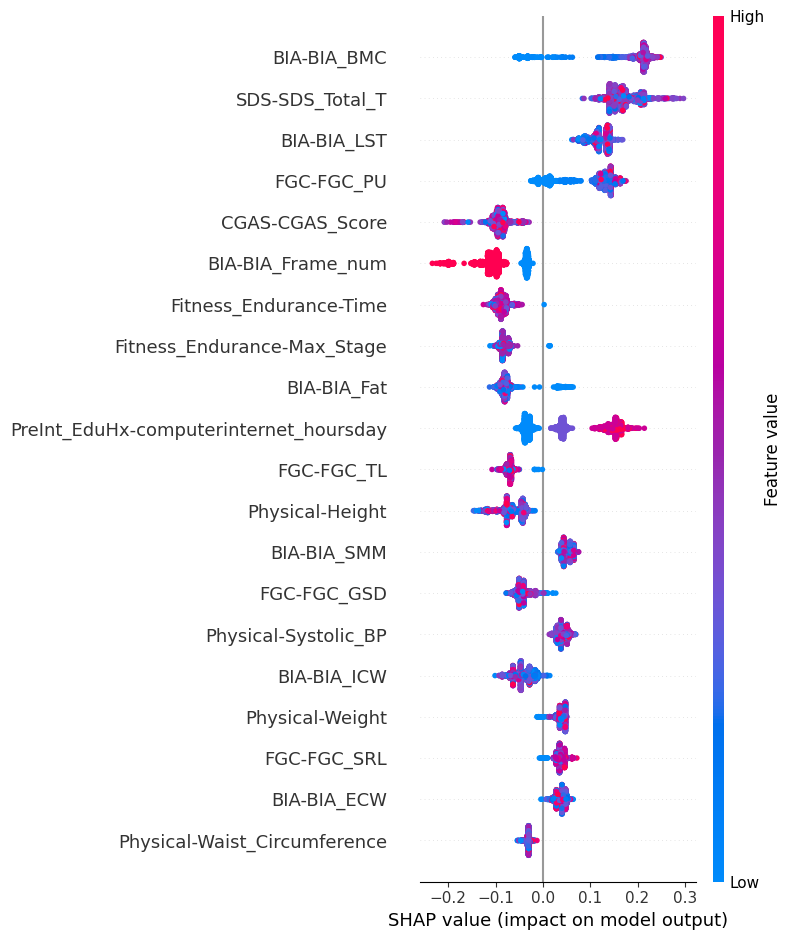

In [7]:
# 1. Definisci la classe da spiegare
target_class = 2

plt.figure(figsize=(20, 6))

# 2. Estrai correttamente i valori SHAP per la classe target
# Se shap_values è un array 3D (pazienti, feature, classi), lo "affettiamo" così:
if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
    shap_values_target = shap_values[:, :, target_class]
else:
    # Fallback nel caso tu abbia una versione vecchia di SHAP che usa le liste
    shap_values_target = shap_values[target_class]

# assegniamo alle feature names i nomi originali delle colonne (se X_test è un DataFrame)

feature_names = df.drop(columns="sii").columns.tolist()

# 3. Crea il Summary Plot usando la matrice corretta
shap.summary_plot(shap_values_target, X_test, plot_type="dot", show=False, feature_names=feature_names)

# plt.title(f'SHAP Summary Plot for XGBoost (Target: Class {target_class})', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# plt.savefig(f'shap_summary_xgb_class{target_class}.pdf', dpi=300, bbox_inches='tight')
plt.show()

<Figure size 800x600 with 0 Axes>

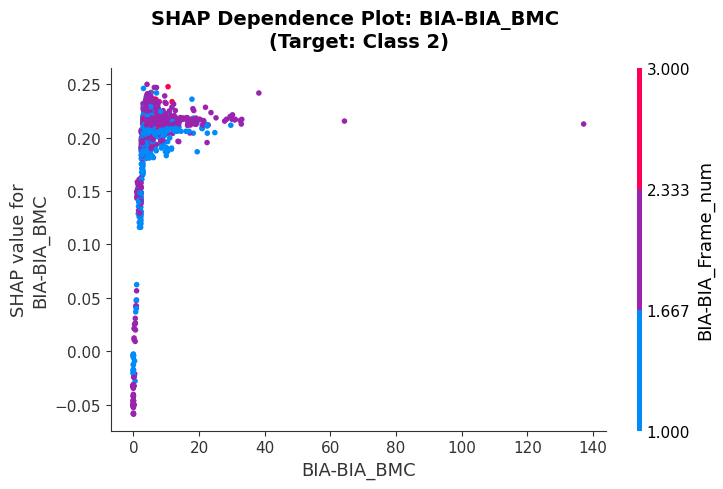

In [8]:
# Definisci la feature da analizzare
# assign feature names to X_test
X_test = pd.DataFrame(X_test, columns=feature_names)
feature_to_plot = 'BIA-BIA_BMC'

plt.figure(figsize=(8, 6))

# Crea il Dependence Plot
# shap.dependence_plot sceglie in automatico la feature con cui c'è più interazione per colorare i punti
shap.dependence_plot(feature_to_plot, shap_values_target, X_test, show=False)

plt.title(f'SHAP Dependence Plot: {feature_to_plot} \n(Target: Class {target_class})', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# plt.savefig(f'shap_dependence_xgb_{feature_to_plot}_class{target_class}.pdf', dpi=300, bbox_inches='tight')
plt.show()

Local Explanation

c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


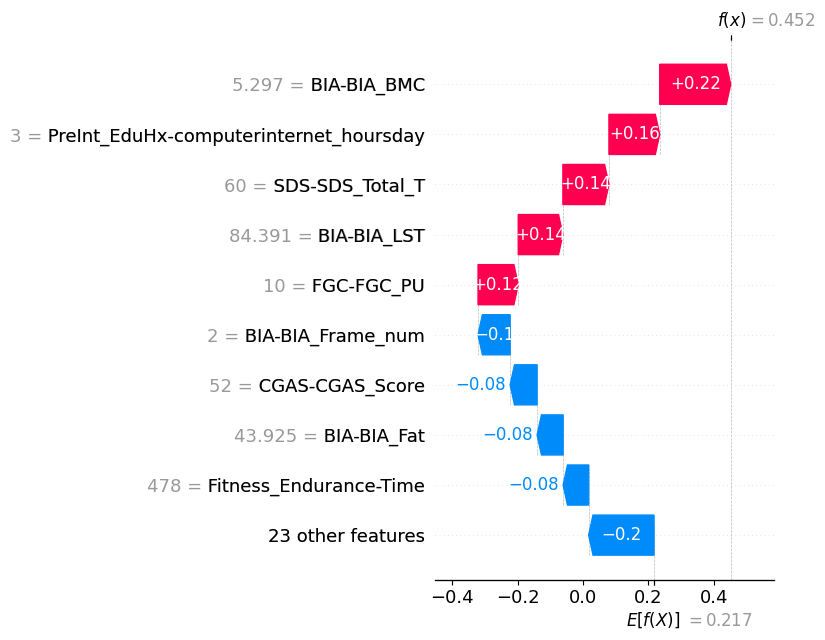

In [13]:
# 1. Seleziona il paziente (es. indice 42 nel test set)
patient_idx = 1200
# target class is the predicted class for that patient
target_class = np.argmax(best_pipeline_xgb.predict_proba(X_test.iloc[patient_idx:patient_idx+1]))

# 2. Crea un oggetto Explanation specifico per quel paziente e per la classe target
# explainer.expected_value è il valore base (il rischio medio prima di guardare le feature)
base_value = explainer.expected_value[target_class]
# Estrai i valori SHAP di un singolo paziente (riga) per una singola classe (profondità)
patient_shap = shap_values[patient_idx, :, target_class]
patient_data = X_test.iloc[patient_idx]

# Crea l'oggetto formale per SHAP
explanation = shap.Explanation(values=patient_shap, 
                               base_values=base_value, 
                               data=patient_data, 
                               feature_names=X_test.columns)

# 3. Disegna il Waterfall plot
plt.figure(figsize=(20, 6))
shap.plots.waterfall(explanation, max_display=10, show=False)

# plt.title(f'SHAP Waterfall Plot - Patient {patient_idx} (Target: Class {target_class})', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()

# plt.savefig(f'shap_waterfall_xgb_patient{patient_idx}_class{target_class}.pdf', dpi=300, bbox_inches='tight')
plt.show()

c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


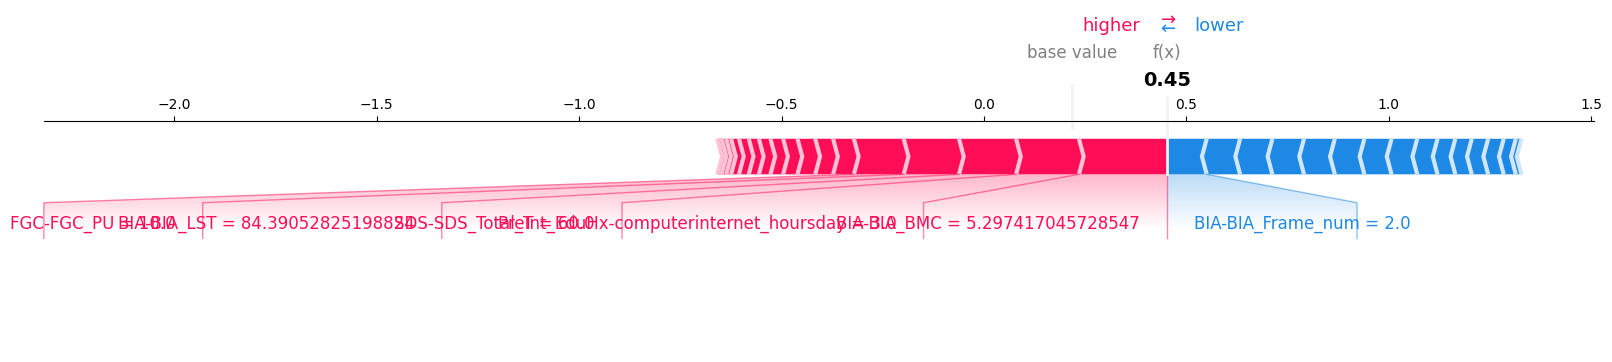

In [12]:
# Inizializza JS per la visualizzazione inline se usi Jupyter Notebook
shap.initjs()

# Seleziona il paziente e la classe
patient_idx = 1200
target_class = np.argmax(best_pipeline_xgb.predict_proba(X_test.iloc[patient_idx:patient_idx+1]))

# Crea il Force Plot
force_plot = shap.force_plot(explainer.expected_value[target_class], 
                             shap_values[patient_idx, :, target_class],
                             X_test.iloc[patient_idx], 
                             matplotlib=True,  # Imposta su True per usare matplotlib (migliore per l'export LaTeX)
                             show=False)

# Nota: la formattazione avanzata con matplotlib=True a volte richiede aggiustamenti manuali
# Salva l'immagine
# plt.savefig(f'shap_forceplot_xgb_patient{patient_idx}_class{target_class}.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 3. BalancedBaggingClassifier

In [14]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.ensemble import BalancedBaggingClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

# =========================================================================
# 1. DEFINIZIONE DELLO SPAZIO DEGLI IPERPARAMETRI (Con prefissi pipeline)
# =========================================================================
param_dist_balanced_bag_dt = {
    # Parametri del BalancedBaggingClassifier (notare il prefisso 'bag__')
    'bag__n_estimators': [50, 100, 200, 300], # Numero di alberi nell'ensemble
    'bag__max_samples': [0.5, 0.7, 0.9, 1.0], # Quanti campioni clonare per ogni albero
    'bag__max_features': [0.5, 0.7, 0.9, 1.0], # Quante feature assegnare a ogni albero
    
    # Parametri del Decision Tree sottostante (notare il doppio prefisso 'bag__estimator__')
    'bag__estimator__max_depth': [None, 10, 20, 30, 40],
    'bag__estimator__criterion': ['gini', 'entropy'],
    'bag__estimator__min_samples_split': [2, 5, 10],
    'bag__estimator__min_samples_leaf': [1, 2, 4]
}

# =========================================================================
# 2. INIZIALIZZAZIONE COMPONENTI E PIPELINE
# =========================================================================
# Configuriamo il Decision Tree di base con la gestione interna dei pesi
dt_base = DecisionTreeClassifier(class_weight='balanced', random_state=42)

# Istanziamo il BalancedBaggingClassifier
# Esegue un down-sampling della classe maggioritaria su ogni singolo bootstrap
balanced_bagging_model = BalancedBaggingClassifier(
    estimator=dt_base, 
    sampling_strategy='auto',
    random_state=42, 
    n_jobs=-1
)

# Costruzione della pipeline sequenziale protetta da Data Leakage
pipeline_balanced_bag_dt = ImbPipeline([
    ('scaler', StandardScaler()),            # Fase 1: Standardizzazione (opzionale per DT, ottima per l'ensemble)
    ('bag', balanced_bagging_model)          # Fase 2: Bilanciamento bootstrap e classificazione
])

# =========================================================================
# 3. CONFIGURAZIONE E AVVIO DELLA RANDOMIZED SEARCH (5-Fold CV)
# =========================================================================
print("Starting Scaled BalancedBagging + Decision Tree Hyperparameter Tuning...")

random_search_balanced_bag_dt = RandomizedSearchCV(
    estimator=pipeline_balanced_bag_dt,
    param_distributions=param_dist_balanced_bag_dt,
    n_iter=40,                        # Esploriamo 40 combinazioni nello spazio dei parametri
    cv=5,                             # 5-Fold Cross-Validation stratificata
    scoring='balanced_accuracy',      # Ottimizzazione focalizzata sulla balanced accuracy
    n_jobs=1,                         # 1 per evitare conflitti di parallelismo (n_jobs=-1 è già dentro il bagging)
    random_state=42,
    verbose=1
)

# Fit sui dati originali sbilanciati a 3 classi
random_search_balanced_bag_dt.fit(X_train, y_train)

# Estrazione della pipeline migliore
best_pipeline_bag_dt = random_search_balanced_bag_dt.best_estimator_

print("\n=== TUNING COMPLETATO ===")
print(f"Best Parameters found: {random_search_balanced_bag_dt.best_params_}")
print(f"Best Balanced Accuracy Score (CV): {random_search_balanced_bag_dt.best_score_:.4f}\n")

# =========================================================================
# 4. VALUTAZIONE FINALE TRAMITE LA TUA FUNZIONE ORIGINALE
# =========================================================================
print("Evaluating Best Balanced Bagging + DT Model on Test Set...")

Starting Scaled BalancedBagging + Decision Tree Hyperparameter Tuning...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

=== TUNING COMPLETATO ===
Best Parameters found: {'bag__n_estimators': 300, 'bag__max_samples': 0.9, 'bag__max_features': 1.0, 'bag__estimator__min_samples_split': 2, 'bag__estimator__min_samples_leaf': 4, 'bag__estimator__max_depth': 30, 'bag__estimator__criterion': 'entropy'}
Best Balanced Accuracy Score (CV): 0.5062

Evaluating Best Balanced Bagging + DT Model on Test Set...


In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn import tree

bagging_model = best_pipeline_bag_dt  # Estrai il modello BalancedBagging dalla pipeline

# 1. Ottieni le previsioni del tuo modello black-box sul test set
# (Assumo che 'bagging_model' sia il tuo BalancedBagging già addestrato)
y_pred_bagging = bagging_model.predict(X_test)

print(f"Balanced Bagging + DT Test Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")

# 2. Inizializza il modello surrogato
# CRITICO: Usa max_depth=3 o 4. Un albero profondo 10 livelli non è interpretabile!
surrogate_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

# 3. Addestra il surrogato a IMITARE il Bagging
# Attenzione: il target qui è y_pred_bagging, NON y_test!
print(X_test.shape, y_pred_bagging.shape)  # Debug: assicurati che le dimensioni siano compatibili
surrogate_tree.fit(X_test, y_pred_bagging)
print(X_test.columns)
print(y_pred_bagging)

c:\Users\leona\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


Balanced Bagging + DT Test Accuracy: 0.5612
(2352, 32) (2352,)
Index(['Basic_Demos-Age', 'Basic_Demos-Sex', 'CGAS-CGAS_Score',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Fitness_Endurance-Max_Stage',
       'Physical-HeartRate', 'Physical-Systolic_BP', 'FGC-FGC_CU',
       'FGC-FGC_GSND', 'FGC-FGC_GSD', 'FGC-FGC_PU', 'FGC-FGC_SRL',
       'FGC-FGC_SRR', 'FGC-FGC_TL', 'BIA-BIA_DEE',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMR',
       'BIA-BIA_ECW', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num', 'BIA-BIA_ICW',
       'BIA-BIA_LDM', 'BIA-BIA_LST', 'BIA-BIA_SMM', 'PAQ_Total',
       'SDS-SDS_Total_T', 'PreInt_EduHx-computerinternet_hoursday',
       'Fitness_Endurance-Time'],
      dtype='object')
[0 0 2 ... 2 0 1]


In [31]:
# 4. Calcola la fedeltà
y_pred_surrogate = surrogate_tree.predict(X_test)
fidelity = accuracy_score(y_pred_bagging, y_pred_surrogate) # Quanto il surrogato imita il bagging

print(f"Surrogate Model Fidelity: {fidelity * 100:.2f}%")

Surrogate Model Fidelity: 78.02%


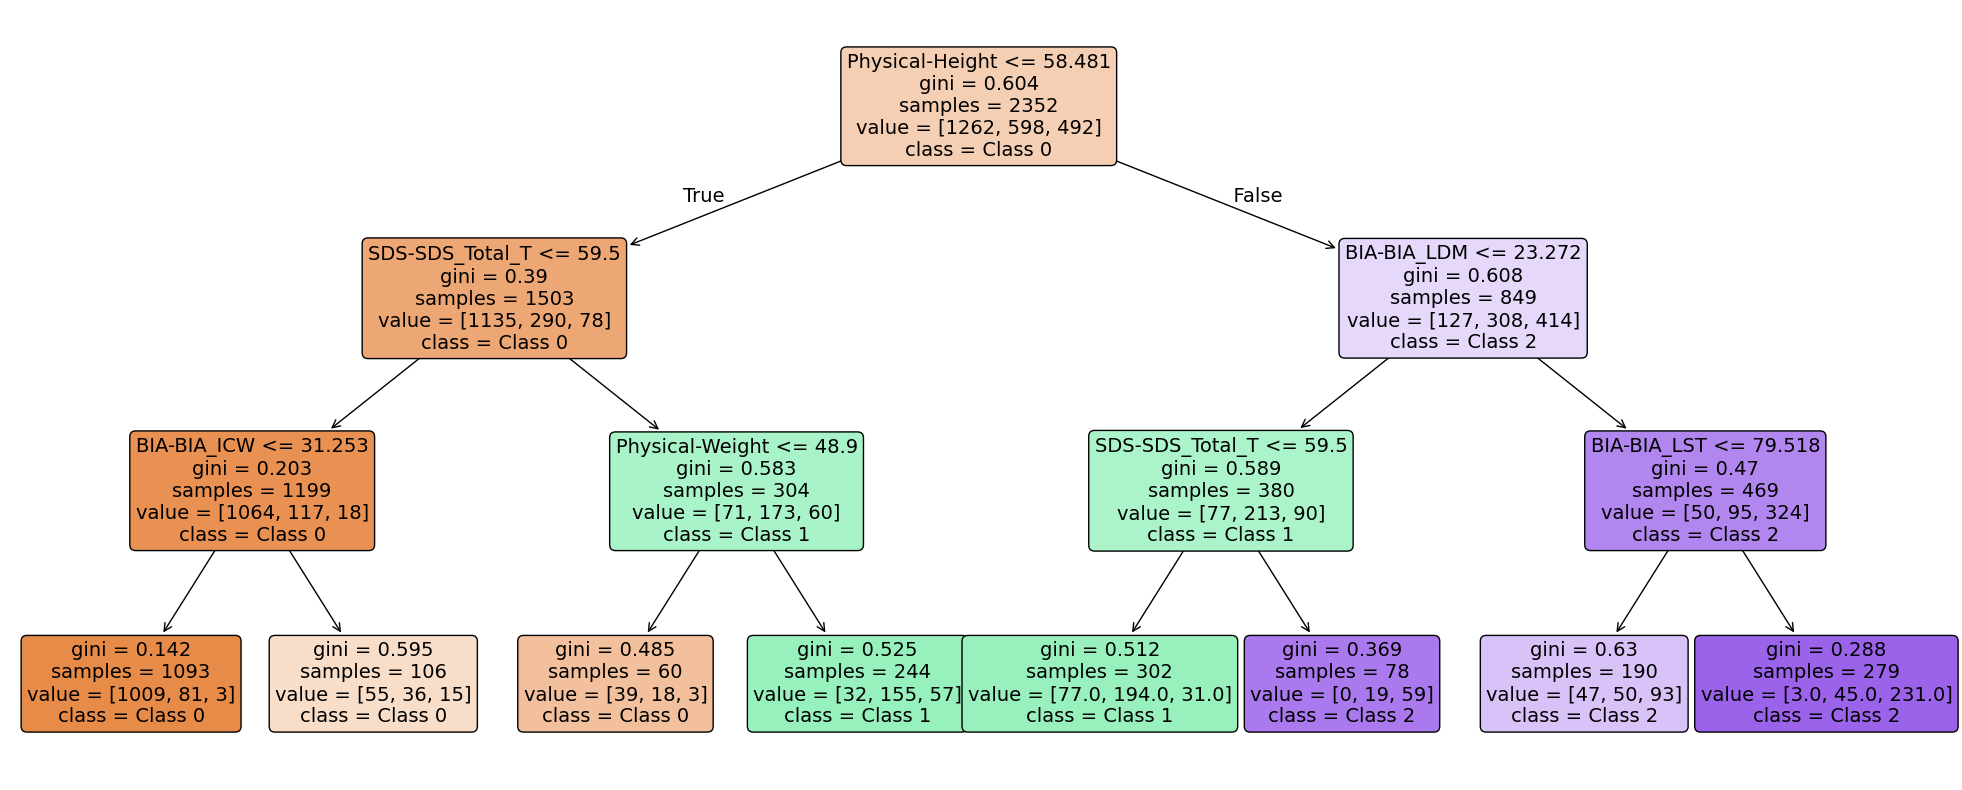

In [41]:
# 5. Visualizza l'albero (i.e., la feature importance in forma di regole del surrogato)
plt.figure(figsize=(25, 10))
tree.plot_tree(surrogate_tree, 
               feature_names=X_test.columns, 
               class_names=['Class 0', 'Class 1', 'Class 2'], 
               filled=True, 
               rounded=True, 
               fontsize=14)

#plt.title(f'Global Surrogate Decision Tree for BalancedBagging \n(Fidelity: {fidelity:.2f})', fontsize=16)
# plt.savefig('surrogate_tree_bagging.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [65]:
i2e = 1200
x = X_test.iloc[i2e]
x 

Basic_Demos-Age                             14.000000
Basic_Demos-Sex                              0.000000
CGAS-CGAS_Score                             52.000000
Physical-Height                             68.030000
Physical-Weight                            118.399667
Physical-Waist_Circumference                29.680979
Physical-Diastolic_BP                       68.000000
Fitness_Endurance-Max_Stage                  5.000000
Physical-HeartRate                          78.000000
Physical-Systolic_BP                       106.000000
FGC-FGC_CU                                  21.000000
FGC-FGC_GSND                                17.600000
FGC-FGC_GSD                                 21.439457
FGC-FGC_PU                                  10.000000
FGC-FGC_SRL                                  8.175675
FGC-FGC_SRR                                  8.000000
FGC-FGC_TL                                  10.000000
BIA-BIA_DEE                               2730.960456
BIA-BIA_Activity_Level_num  

In [66]:
# from record to string
x = x.to_frame().T  # Converti la Serie in un DataFrame con una sola riga
print(x)

      Basic_Demos-Age  Basic_Demos-Sex  CGAS-CGAS_Score  Physical-Height  \
1200             14.0              0.0             52.0            68.03   

      Physical-Weight  Physical-Waist_Circumference  Physical-Diastolic_BP  \
1200       118.399667                     29.680979                   68.0   

      Fitness_Endurance-Max_Stage  Physical-HeartRate  Physical-Systolic_BP  \
1200                          5.0                78.0                 106.0   

      ...  BIA-BIA_Fat  BIA-BIA_Frame_num  BIA-BIA_ICW  BIA-BIA_LDM  \
1200  ...    43.924545                2.0    35.689856    27.027433   

      BIA-BIA_LST  BIA-BIA_SMM  PAQ_Total  SDS-SDS_Total_T  \
1200    84.390528    45.525511        2.0             60.0   

      PreInt_EduHx-computerinternet_hoursday  Fitness_Endurance-Time  
1200                                     3.0                   478.0  

[1 rows x 32 columns]


In [67]:
# surrogate prediction of x
bb_outcome = bagging_model.predict(x.values.reshape(1, -1))[0]
class_values = ['Class 0', 'Class 1', 'Class 2']
bb_outcome_str = class_values[bb_outcome]

print('bb(x) = { %s }' % bb_outcome_str)

bb(x) = { Class 2 }
